# V1.8 — Growth memoization & write-back correctness

**Targets:** Decision #11; ARCHITECTURE §III.1 ("Growth — writing the implicit field"). Protocol §V1.8.

**Claim.** Evaluating a **memoized growth trace** at a given `(time, LOD)` is deterministic and
**matches a fresh (non-memoized) growth run**; and a **write-back** (a recorded cut/wound)
correctly **invalidates stale memoized sub-results**, so later growth **heals around the wound**
rather than replaying the pre-wound limb. The architecture's load-bearing caveat: *"memoization
keys must include the write-back state."* If they don't, a post-cut query returns the cached
pre-wound limb — a **stale replay** — breaking the growth→interaction→heal loop and the
kilobyte-storage promise → **REDESIGN** the cache-key / invalidation scheme.

**Mechanism under test** (`growth.py`): a dimension-agnostic field-biased L-system front (apical
meristems sensing a light field, branching by a seeded rule, depositing ringed layers). The
load-bearing design point: every branch's RNG stream is derived by **hashing its key** (a stable
blake2b digest of its lineage), *not* the global draw order — so a subtree is a pure deterministic
function of `(seed, params, key, time, LOD, write-back)`, which is what makes per-subtree
memoization **bit-reproducible** (Decision #3 / V0.5 — "the program IS the asset"; builtin
`hash()` is salted and would break this). LOD = branch-order truncation ("truncation IS LOD").

**Independent oracle:** a from-scratch, non-memoized grow (intact, and a grow-with-the-cut for
the healed tree). Demonstrated in **both 2D and 3D** (the logic is dimension-independent).

**Note.** Back to **CPU/numpy** (tiny seeded trees, latency-bound) after V1.7's GPU FE work.

| # | Criterion | Pre-registered threshold (frozen) |
|---|---|---|
| A1 | **memoized == fresh** | bit-exact for **100%** of `(time, LOD)` samples, both 2D & 3D (tol = 0) |
| A2 | **determinism** | repeated grow bit-identical (stable digest equal) |
| B1 | **correct key → heals** | write-back in the key ⇒ **0 stale-replay incidents**; healed == oracle (bit-exact) |
| B2 | **necessity** | write-back **omitted** from the key ⇒ stale-replay incidents **≥ 1** |
| B3 | **healing** | callus deposited over the wound (**> 0**); the severed limb is pruned (absent) |


In [1]:
"""(1) Setup — imports, frozen constants, the guaranteed-severing cut selector."""
import sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

REPO = pathlib.Path.cwd()
while not (REPO / "src" / "verification" / "oracles" / "growth.py").exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "src" / "verification" / "oracles"))
RESULTS = REPO / "verification_notebooks" / "phase1" / "results"

import growth as gr
import determinism as det

# ---- frozen constants (calibrated in _calib_v18.py; frozen with margin BEFORE this runs) ----
SEED = 0
DIMS = (2, 3)

def best_cut(gp, seed):
    """Pick the (branch, sever-step) that removes the MOST nodes — a strong, non-vacuous cut.
    Returns (cuts, intact, oracle_cut)."""
    intact = gr.grow(gp.max_gen, gp.max_order, gp=gp, seed=seed)
    cands = {}
    for n in intact:
        if n[5] == gr.LAYER_WOOD and len(n[0]) >= 1:
            cands[n[0][:1]] = cands.get(n[0][:1], 0) + 1
    best, best_oc, best_sev = None, None, -1
    for b in cands:
        for cs in (1, 2):
            oc = gr.grow(gp.max_gen, gp.max_order, cuts={b: cs}, gp=gp, seed=seed)
            sev = len(intact - oc)
            if sev > best_sev:
                best, best_oc, best_sev = {b: cs}, oc, sev
    return best, intact, best_oc

print("CPU/numpy; growth in dims", DIMS)


Warp 1.14.0 initialized:
   CUDA Toolkit 12.9, Driver 13.0
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA GeForce RTX 4090" (24 GiB, sm_89, mempool enabled)
   Kernel cache:
     /root/.cache/warp/1.14.0
CPU/numpy; growth in dims (2, 3)


## (A) Memoized trace evaluation == fresh grow  (theorem / determinism)

Grow the full trace once (the compact memoized object), then **evaluate** it at every `(time,
LOD)` — a pure filter — and compare, **bit-for-bit**, to a fresh from-scratch grow to that
`(time, LOD)`. Equality for all samples means growth is prefix- and truncation-consistent and the
hashed sub-seeding is perfectly deterministic.

In [2]:
"""(2) A: memo==fresh over the full (time,LOD) grid, both dims; + determinism."""
A_results = {}
A_mismatch_total = 0
A_det_ok = True
for dim in DIMS:
    gp = gr.GrowthParams(dim=dim)
    trace = gr.full_trace(gp, SEED)
    n_samples, mism = 0, 0
    match_matrix = np.zeros((gp.max_gen + 1, gp.max_order + 1), dtype=bool)
    for t in range(gp.max_gen + 1):
        for lod in range(gp.max_order + 1):
            memo = gr.evaluate(trace, t, lod)
            fresh = gr.grow(t, lod, gp=gp, seed=SEED, cache=None)
            ok = (memo == fresh) and det.bitwise_equal(gr.wood_positions(memo),
                                                        gr.wood_positions(fresh))
            match_matrix[t, lod] = ok
            n_samples += 1
            mism += (0 if ok else 1)
    det_ok = gr.trace_digest(gr.full_trace(gp, SEED)) == gr.trace_digest(gr.full_trace(gp, SEED))
    A_results[dim] = dict(gp=gp, trace=trace, match=match_matrix, n=n_samples, mism=mism, det=det_ok)
    A_mismatch_total += mism
    A_det_ok = A_det_ok and det_ok
    print("  dim=%d: memo==fresh %d/%d samples (mismatches=%d)  repeat-determinism=%s"
          % (dim, n_samples - mism, n_samples, mism, det_ok))

A1 = A_mismatch_total == 0
A2 = A_det_ok
print("  [A1] memo==fresh bit-exact (all dims): %s   [A2] determinism: %s" % (A1, A2))


  dim=2: memo==fresh 115/115 samples (mismatches=0)  repeat-determinism=True


  dim=3: memo==fresh 115/115 samples (mismatches=0)  repeat-determinism=True
  [A1] memo==fresh bit-exact (all dims): True   [A2] determinism: True


## (B) Write-back invalidation, healing, and key necessity  (empirical)

Warm a subtree cache on the **intact** tree, then query the asset **after a cut**. With the
write-back state in the cache key the affected subtrees miss and recompute — the wound heals
(callus grows, severed limb gone). With the write-back **omitted**, the stale intact subtrees are
served — the severed limb reappears (a *stale replay*). This mirrors V1.1's "ambiguous without the
cascade": the safeguard is *necessary*, shown by removing it.

In [3]:
"""(3) B: correct vs buggy cache key; healing; necessity. Both dims."""
B_results = {}
B1_good_stale_max, B1_heal_eq, B2_bad_stale_min, B3_callus_min, B3_pruned_ok = 0, True, 10**9, 10**9, True
for dim in DIMS:
    gp = gr.GrowthParams(dim=dim)
    T, LOD = gp.max_gen, gp.max_order
    cuts, intact, oracle_cut = best_cut(gp, SEED)

    # correct key: warm intact, query cut
    cg = {}; gr.grow(T, LOD, cuts={}, gp=gp, seed=SEED, cache=cg, include_wb=True)
    good = gr.grow(T, LOD, cuts=cuts, gp=gp, seed=SEED, cache=cg, include_wb=True)
    good_stale = gr.stale_replay_count(good, oracle_cut)
    heal_eq = (good == oracle_cut)

    # buggy key: warm intact, query cut -> stale replay
    cb = {}; gr.grow(T, LOD, cuts={}, gp=gp, seed=SEED, cache=cb, include_wb=False)
    bad = gr.grow(T, LOD, cuts=cuts, gp=gp, seed=SEED, cache=cb, include_wb=False)
    bad_stale = gr.stale_replay_count(bad, oracle_cut)

    # healing diagnostics
    cut_key = next(iter(cuts))
    sev = gr.severed_subtree_keys(cut_key)
    cutline_intact = {n for n in intact if sev(n)}
    removed = cutline_intact - {n for n in oracle_cut if sev(n)}
    callus = gr.callus_count(oracle_cut)
    pruned_ok = (len(removed) > 0) and removed.isdisjoint(oracle_cut)

    B_results[dim] = dict(gp=gp, cuts=cuts, intact=intact, oracle=oracle_cut, good=good, bad=bad,
                          good_stale=good_stale, bad_stale=bad_stale, callus=callus,
                          removed=removed, cut_key=cut_key)
    B1_good_stale_max = max(B1_good_stale_max, good_stale)
    B1_heal_eq = B1_heal_eq and heal_eq
    B2_bad_stale_min = min(B2_bad_stale_min, bad_stale)
    B3_callus_min = min(B3_callus_min, callus)
    B3_pruned_ok = B3_pruned_ok and pruned_ok
    print("  dim=%d cut=%s: correct-key stale=%d healed==oracle=%s | buggy-key stale=%d | "
          "callus=%d limb_pruned=%d" % (dim, cuts, good_stale, heal_eq, bad_stale, callus, len(removed)))

B1 = (B1_good_stale_max == 0) and B1_heal_eq
B2 = B2_bad_stale_min >= 1
B3 = (B3_callus_min > 0) and B3_pruned_ok
print("  [B1] correct-key heals (0 stale, ==oracle): %s   [B2] buggy-key stale>=1: %s   "
      "[B3] healing (callus + pruned): %s" % (B1, B2, B3))


  dim=2 cut={((10, 1),): 1}: correct-key stale=0 healed==oracle=True | buggy-key stale=150 | callus=16 limb_pruned=150


  dim=3 cut={((9, 0),): 1}: correct-key stale=0 healed==oracle=True | buggy-key stale=119 | callus=24 limb_pruned=119
  [B1] correct-key heals (0 stale, ==oracle): True   [B2] buggy-key stale>=1: True   [B3] healing (callus + pruned): True


## Figure

saved /workspace/nebula/verification_notebooks/phase1/results/V1_8_growth_writeback.png


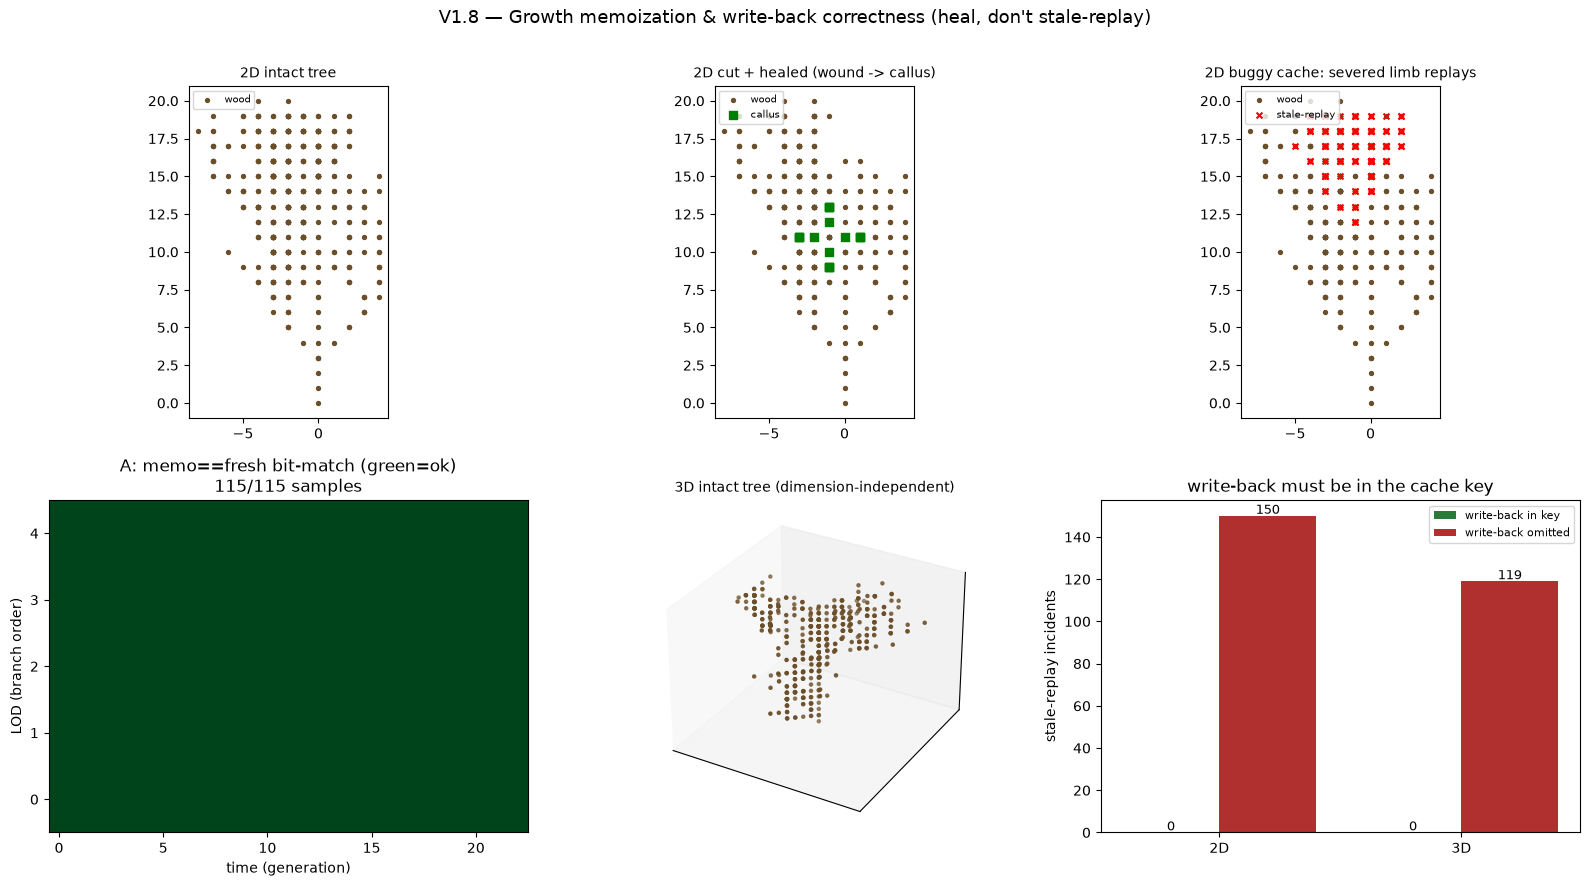

In [4]:
"""(4) Figure: trees (intact / cut+healed / stale-replay bug), match matrix, 3D tree, stale bars."""
fig = plt.figure(figsize=(16, 9))
B2d = B_results[2]; A2d = A_results[2]

def scatter2d(ax, nodes, title, hi=None):
    wood = np.array([n[4] for n in nodes if n[5] == gr.LAYER_WOOD])
    cal = np.array([n[4] for n in nodes if n[5] == gr.LAYER_CALLUS])
    if len(wood):
        ax.scatter(wood[:, 0], wood[:, 1], s=8, c="#6b4f2a", label="wood")
    if len(cal):
        ax.scatter(cal[:, 0], cal[:, 1], s=26, c="green", marker="s", label="callus")
    if hi is not None and len(hi):
        h = np.array([n[4] for n in hi])
        ax.scatter(h[:, 0], h[:, 1], s=18, c="red", marker="x", label="stale-replay")
    ax.set_title(title, fontsize=10); ax.set_aspect("equal"); ax.legend(fontsize=7, loc="upper left")

scatter2d(fig.add_subplot(231), B2d["intact"], "2D intact tree")
scatter2d(fig.add_subplot(232), B2d["oracle"], "2D cut + healed (wound -> callus)")
# stale-replay: buggy result, highlight the nodes that should have been invalidated
stale_nodes = B2d["bad"] - B2d["oracle"]
scatter2d(fig.add_subplot(233), B2d["bad"], "2D buggy cache: severed limb replays", hi=stale_nodes)

# (time,LOD) bit-match matrix (2D)
ax = fig.add_subplot(234)
ax.imshow(A2d["match"].T, origin="lower", aspect="auto", cmap="Greens", vmin=0, vmax=1)
ax.set_xlabel("time (generation)"); ax.set_ylabel("LOD (branch order)")
ax.set_title("A: memo==fresh bit-match (green=ok)\n%d/%d samples" % (A2d["n"] - A2d["mism"], A2d["n"]))

# 3D intact tree
ax = fig.add_subplot(235, projection="3d")
w3 = np.array([n[4] for n in B_results[3]["intact"] if n[5] == gr.LAYER_WOOD])
c3 = np.array([n[4] for n in B_results[3]["oracle"] if n[5] == gr.LAYER_CALLUS])
ax.scatter(w3[:, 0], w3[:, 1], w3[:, 2], s=5, c="#6b4f2a")
ax.set_title("3D intact tree (dimension-independent)", fontsize=10)
ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

# stale incident bars
ax = fig.add_subplot(236)
labels = ["2D", "3D"]
good_v = [B_results[d]["good_stale"] for d in (2, 3)]
bad_v = [B_results[d]["bad_stale"] for d in (2, 3)]
x = np.arange(2)
ax.bar(x - 0.2, good_v, 0.4, label="write-back in key", color="#2a7a3a")
ax.bar(x + 0.2, bad_v, 0.4, label="write-back omitted", color="#b03030")
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel("stale-replay incidents")
ax.set_title("write-back must be in the cache key"); ax.legend(fontsize=8)
for i, v in enumerate(good_v):
    ax.text(i - 0.2, v + 1, str(v), ha="center", fontsize=9)
for i, v in enumerate(bad_v):
    ax.text(i + 0.2, v + 1, str(v), ha="center", fontsize=9)

fig.suptitle("V1.8 — Growth memoization & write-back correctness (heal, don't stale-replay)",
             fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(RESULTS / "V1_8_growth_writeback.png", dpi=110, bbox_inches="tight")
print("saved", RESULTS / "V1_8_growth_writeback.png")
plt.show()


In [5]:
"""(5) Frozen verdict."""
def verdict(name, passed, detail):
    print("  [%s] %-36s %s" % ("OK" if passed else "XX", name, detail))

print("=" * 86)
print("V1.8 VERDICT — growth memoization & write-back correctness")
print("=" * 86)
verdict("A1 memoized == fresh (bit-exact)", A1,
        "mismatches=%d over both dims' (time,LOD) grids" % A_mismatch_total)
verdict("A2 determinism (repeat grow)", A2, "stable digests equal")
verdict("B1 correct key -> heals", B1,
        "max stale=%d, healed==oracle=%s" % (B1_good_stale_max, B1_heal_eq))
verdict("B2 necessity (buggy key replays)", B2, "min stale incidents=%d (>=1)" % B2_bad_stale_min)
verdict("B3 healing (callus + pruned)", B3, "min callus=%d, limb pruned & absent" % B3_callus_min)

ALL_PASS = all([A1, A2, B1, B2, B3])
print("-" * 86)
if ALL_PASS:
    print("  V1.8 OVERALL: PASS")
    print("  -> A memoized growth trace evaluates bit-exactly to a fresh grow at any (time,LOD),")
    print("     and a write-back correctly invalidates stale sub-results so growth heals around the")
    print("     wound. Decision #11 holds. Necessity shown: omitting the write-back from the cache")
    print("     key produces stale replays (the severed limb reappears) -- the key MUST include it.")
else:
    print("  V1.8 OVERALL: FAIL - see outcome class above (failure class: REDESIGN).")
print("=" * 86)
assert ALL_PASS, "V1.8 did not pass - see verdict above."


V1.8 VERDICT — growth memoization & write-back correctness
  [OK] A1 memoized == fresh (bit-exact)     mismatches=0 over both dims' (time,LOD) grids
  [OK] A2 determinism (repeat grow)         stable digests equal
  [OK] B1 correct key -> heals              max stale=0, healed==oracle=True
  [OK] B2 necessity (buggy key replays)     min stale incidents=119 (>=1)
  [OK] B3 healing (callus + pruned)         min callus=16, limb pruned & absent
--------------------------------------------------------------------------------------
  V1.8 OVERALL: PASS
  -> A memoized growth trace evaluates bit-exactly to a fresh grow at any (time,LOD),
     and a write-back correctly invalidates stale sub-results so growth heals around the
     wound. Decision #11 holds. Necessity shown: omitting the write-back from the cache
     key produces stale replays (the severed limb reappears) -- the key MUST include it.
